In [ ]:
#!pip install mplfinance

In [ ]:
#!pip install yfinance

In [ ]:
import pandas as pd
import yfinance as yf
import mplfinance as mpf

In [3]:
data = yf.download('AAPL', start='2020-01-01', end='2023-01-01')

[*********************100%***********************]  1 of 1 completed


In [29]:
if isinstance(data, pd.DataFrame):
    print("Data is a DataFrame")

Data is a DataFrame


In [30]:
if isinstance(data.columns, pd.MultiIndex):
    print("Data is a DataFrame")
    data.columns = data.columns.droplevel(1)

Data is a DataFrame


In [31]:
data.head(10)

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200
2020-01-09,74.568810,74.761472,73.742758,73.993218,170108400
2020-01-10,74.737381,75.300934,74.236454,74.802410,140644800
2020-01-13,76.334061,76.360556,74.934828,75.052841,121532000
2020-01-14,75.303322,76.480993,75.180503,76.271471,161954400


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   756 non-null    float64
 1   (High, AAPL)    756 non-null    float64
 2   (Low, AAPL)     756 non-null    float64
 3   (Open, AAPL)    756 non-null    float64
 4   (Volume, AAPL)  756 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.4 KB


In [6]:
data.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [7]:
data.describe()


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,756.000000,756.000000,756.000000,756.000000,7.560000e+02
mean,127.128754,128.671053,125.473652,127.051112,1.120920e+08
std,30.301251,30.577591,30.020452,30.329239,5.602586e+07
min,54.163708,55.160705,51.324804,55.059316,3.519590e+07
25%,112.264128,113.753663,110.812220,112.443586,7.636470e+07
50%,132.485184,133.613799,130.532798,132.307388,9.493580e+07
75%,147.635811,148.798284,145.698887,147.005579,1.296327e+08
max,177.939728,178.848946,175.114365,178.545881,4.265100e+08


# Exploratory Data Analysis (EDA) on the stock data

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 1400x800 with 0 Axes>

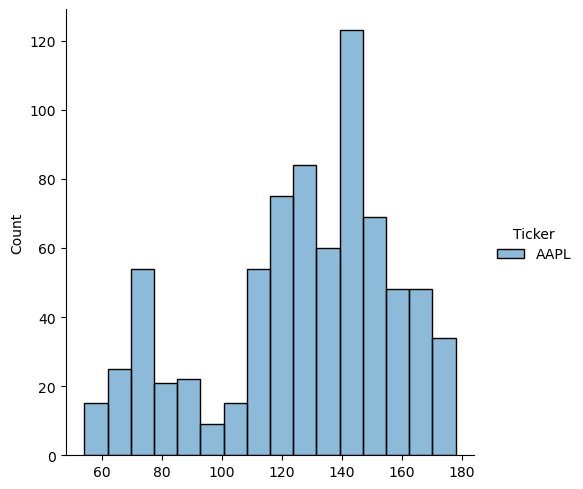

In [9]:
plt.figure(figsize=(14, 8))
sns.displot(data['Close'])
plt.show() 

<Figure size 1400x800 with 0 Axes>

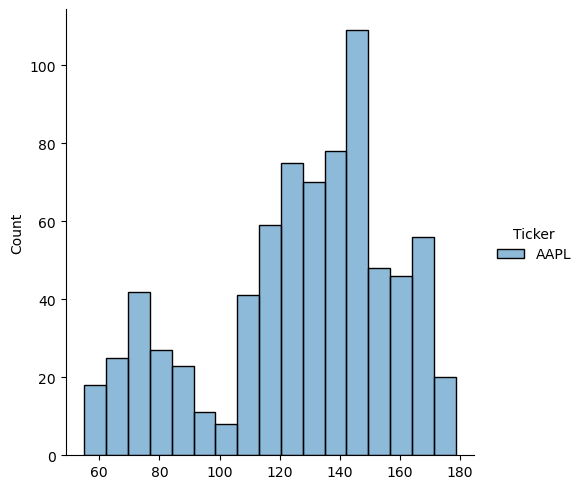

In [10]:
plt.figure(figsize=(14, 8))
sns.displot(data['Open'])
plt.show()

<Figure size 1400x800 with 0 Axes>

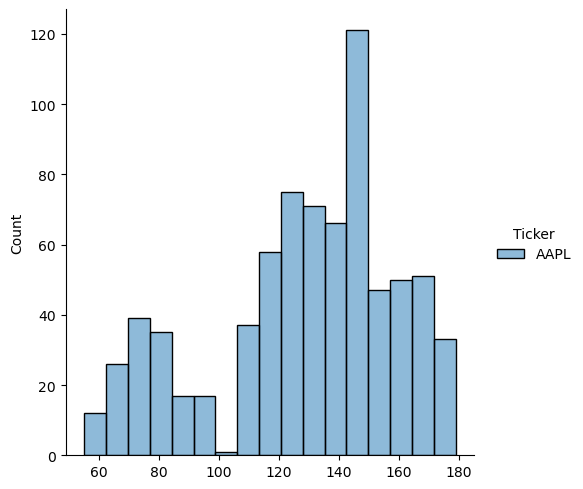

In [11]:
plt.figure(figsize=(14, 8))
sns.displot(data['High'])
plt.show()

<Figure size 1400x800 with 0 Axes>

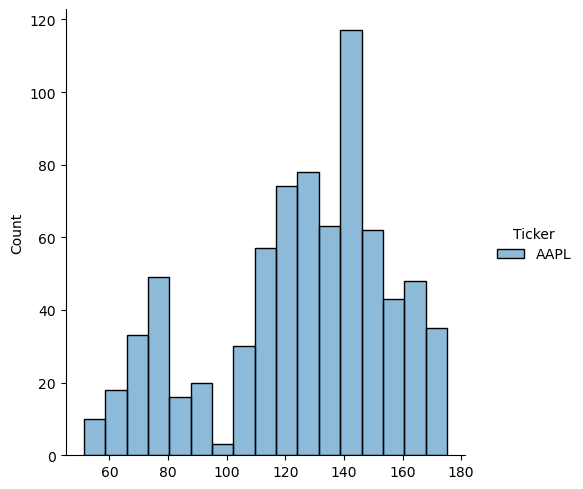

In [12]:
plt.figure(figsize=(14, 8))
sns.displot(data['Low'])
plt.show()

In [21]:
data.head()
type(data['Open'])

pandas.core.frame.DataFrame

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   756 non-null    float64
 1   (High, AAPL)    756 non-null    float64
 2   (Low, AAPL)     756 non-null    float64
 3   (Open, AAPL)    756 non-null    float64
 4   (Volume, AAPL)  756 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.4 KB


In [26]:
data['Open'] = data['Open'].astype(float)   

c:\Users\edgar\anaconda3\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


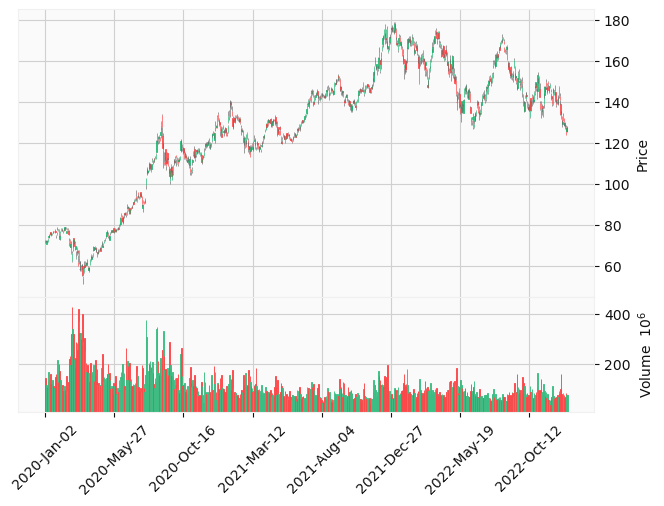

In [32]:
mpf.plot(
    data,
    type="candle",
    volume=True,
    style="yahoo"
)

Text(0.5, 1.0, 'Close Price with 20-Day Moving Average')

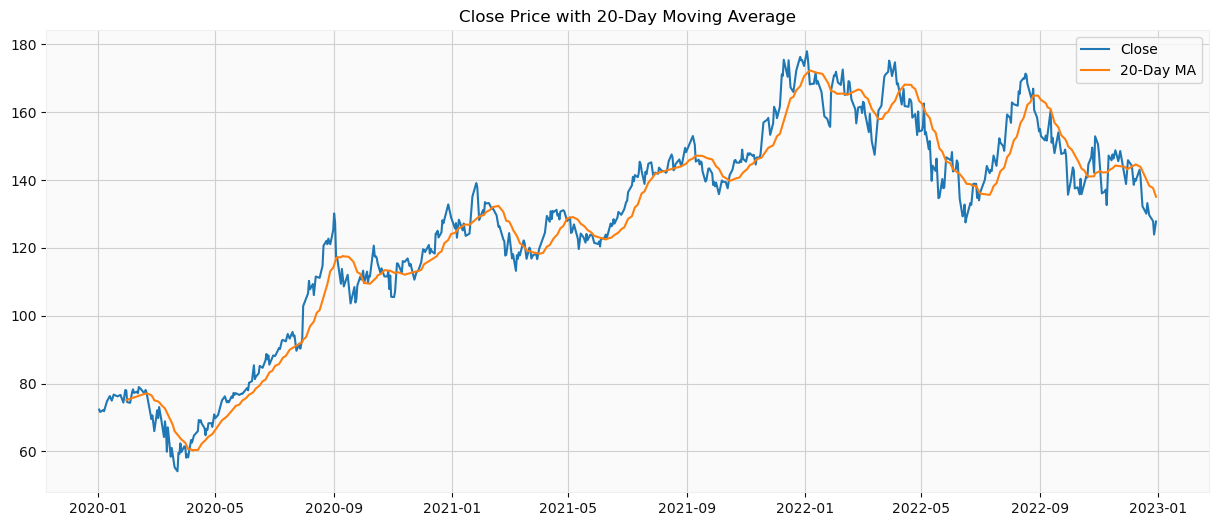

In [33]:
data["MA20"] = data["Close"].rolling(20).mean()

plt.figure(figsize=(15,6))

plt.plot(data.index, data["Close"], label="Close")
plt.plot(data.index, data["MA20"], label="20-Day MA")

plt.legend()
plt.title("Close Price with 20-Day Moving Average")

In [34]:
data['Close']

Date
2020-01-02     72.333870
2020-01-03     71.630661
2020-01-06     72.201416
2020-01-07     71.861847
2020-01-08     73.017838
                 ...    
2022-12-23    129.659409
2022-12-27    127.859947
2022-12-28    123.936539
2022-12-29    127.446953
2022-12-30    127.761581
Name: Close, Length: 756, dtype: float64

## Feature Enginering

In [36]:
data.head(30)

Price,Close,High,Low,Open,Volume,MA20
Date,,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400,NaN
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,NaN
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,NaN
2020-01-09,74.568810,74.761472,73.742758,73.993218,170108400,NaN
2020-01-10,74.737381,75.300934,74.236454,74.802410,140644800,NaN
2020-01-13,76.334061,76.360556,74.934828,75.052841,121532000,NaN
2020-01-14,75.303322,76.480993,75.180503,76.271471,161954400,NaN


In [ ]:
data["MA50_Close"] = data["Close"].rolling(50).mean()
data.head(60)

Price,Close,High,Low,Open,Volume,MA20,MA50,MA50_Close
Date,,,,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400,NaN,NaN,NaN
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,NaN,NaN,NaN
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,NaN
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,NaN
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,NaN,NaN,NaN
2020-01-09,74.568810,74.761472,73.742758,73.993218,170108400,NaN,NaN,NaN
2020-01-10,74.737381,75.300934,74.236454,74.802410,140644800,NaN,NaN,NaN
2020-01-13,76.334061,76.360556,74.934828,75.052841,121532000,NaN,NaN,NaN
2020-01-14,75.303322,76.480993,75.180503,76.271471,161954400,NaN,NaN,NaN


In [42]:
data['Daily_Return'] = data['Close'].pct_change()
data.head(60)

Price,Close,High,Low,Open,Volume,MA20,MA50,MA50_Close,Daily_Return
Date,,,,,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400,NaN,NaN,NaN,NaN
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800,NaN,NaN,NaN,-0.009722
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200,NaN,NaN,NaN,0.007968
2020-01-07,71.861847,72.466330,71.642689,72.211049,108872000,NaN,NaN,NaN,-0.004703
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200,NaN,NaN,NaN,0.016086
2020-01-09,74.568810,74.761472,73.742758,73.993218,170108400,NaN,NaN,NaN,0.021241
2020-01-10,74.737381,75.300934,74.236454,74.802410,140644800,NaN,NaN,NaN,0.002261
2020-01-13,76.334061,76.360556,74.934828,75.052841,121532000,NaN,NaN,NaN,0.021364
2020-01-14,75.303322,76.480993,75.180503,76.271471,161954400,NaN,NaN,NaN,-0.013503
